In [ ]:
from IPython.display import HTML
HTML("<style>.jp-InputArea {display:none;}</style>")

### Eval SRRIP rrpv value

* Maybe maxrrpv@3 ages too fast
  - Too fast to learn anything
  - Optimal should be associativy size

In [ ]:
# Data collection: Sweep vanilla SRRIP with different max RRPVs and hit deltas
python3 ./scripts/run_belady_sweep.py  \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --policies belady,lfu,srrip \
  --srrip-max-rrpvs 3,5,8,12,15 \
  --srrip-hit-deltas 1 \
  --slurm --slurm-time 04:00:00

In [33]:
# Data parsing: Collect vanilla SRRIP results
!../scripts/synch_folder.sh belady_sweep

!python3 ../scripts/run_belady_sweep.py \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --policies belady,lfu,srrip \
  --srrip-max-rrpvs 3,5,8,12,15 \
  --srrip-hit-deltas 1 \
  --collect-existing-results

Syncing experiment: belady_sweep
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
./
belady_sweep_summary.csv
plot_lookup_summary.csv

sent 176 bytes  received 3,496 bytes  2,448.00 bytes/sec
total size is 96,432  speedup is 26.26
Total configurations: 5
Collected existing results: ok=5, missing=0
Summary written to data/belady_sweep/belady_sweep_summary.csv


Lookup summary written to data/belady_sweep/plot_lookup_summary.csv
Found 5, missing 0
Baseline values for non-varied features:
  ew=selected_qualcomm_srv_ap|s=64|w=16
Bar values for SRRIP Max RRPV:
  Belady @ 3: 0.496637
  Belady @ 5: 0.496629
  Belady @ 8: 0.496742
  Belady @ 12: 0.496692
  Belady @ 15: 0.496726
  LFU @ 3: 0.738925
  LFU @ 5: 0.738838
  LFU @ 8: 0.738997
  LFU @ 12: 0.739055
  LFU @ 15: 0.739127
  Vanilla SRRIP @ 3: 0.989785
  Vanilla SRRIP @ 5: 0.989790
  Vanilla SRRIP @ 8: 0.989790
  Vanilla SRRIP @ 12: 0.989790
  Vanilla SRRIP @ 15: 0.989790
Skipping eval_workload: only one feature value after fixing others to baseline.
Skipping num_sets: only one feature value after fixing others to baseline.
Skipping num_ways: only one feature value after fixing others to baseline.
Generated plots:
  figures/belady_sweep/belady_lookup_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_srrip_max_rrpv.multi_bar_miss_rates_vs_srrip_max_rrpv.png


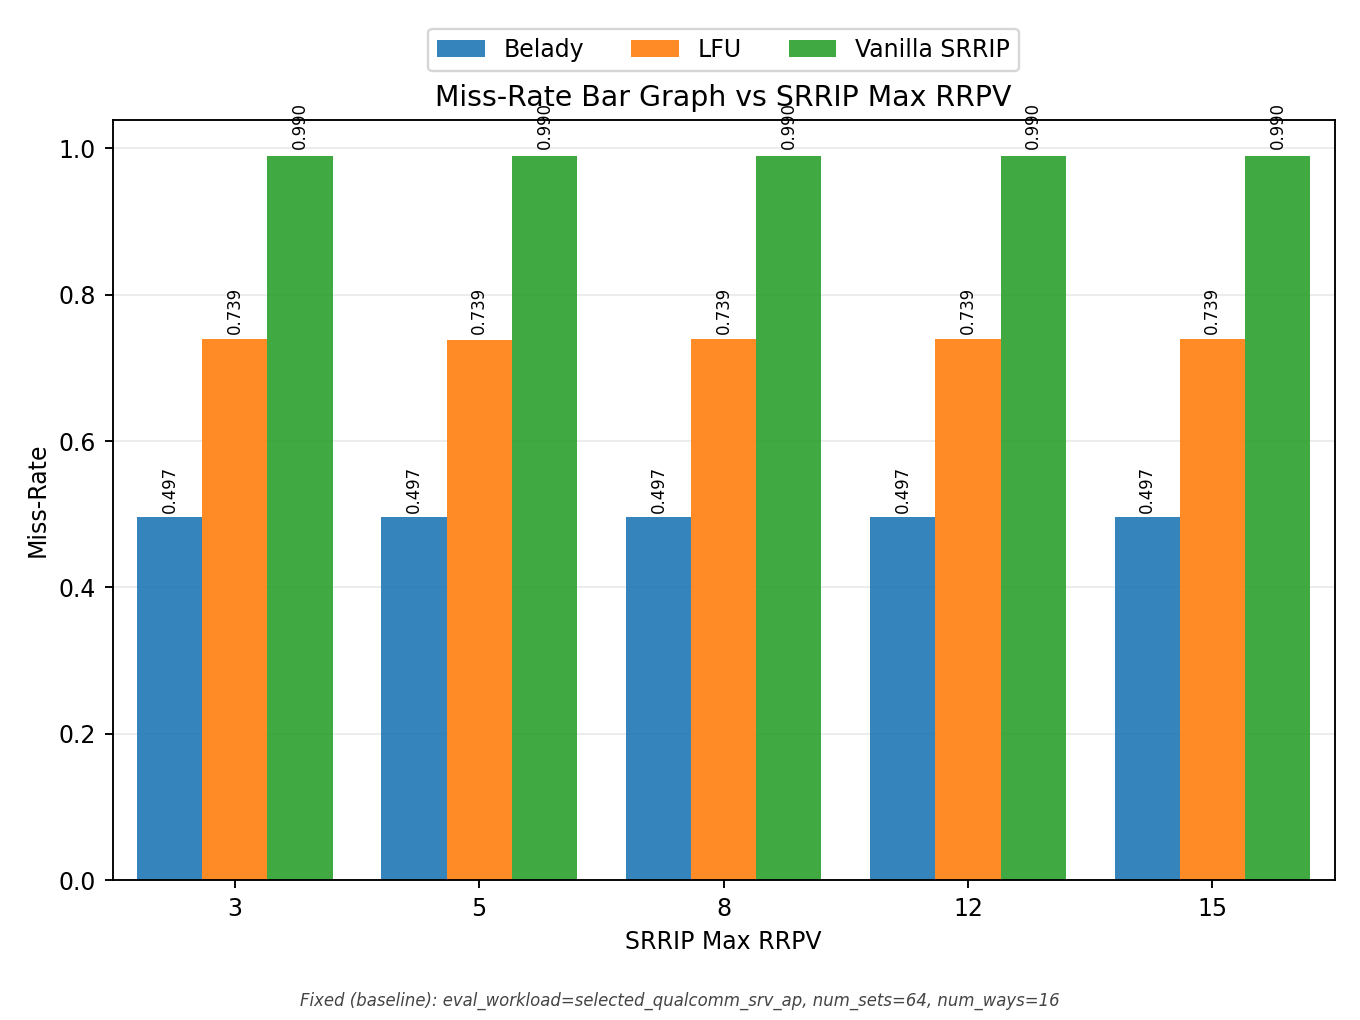

In [34]:
# Plotting: Compare vanilla SRRIP variants with LFU and Belady
!python3 ../scripts/plot_belady_sweep_results.py \
  --sweep-summary-csv ./data/belady_sweep/belady_sweep_summary.csv \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --policies belady,lfu,srrip \
  --srrip-max-rrpvs 3,5,8,12,15 \
  --summary-csv data/belady_sweep/plot_lookup_summary.csv \
  --plot-file-format png

from IPython.display import Image, display
display(Image("figures/belady_sweep/belady_lookup_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_srrip_max_rrpv.multi_bar_miss_rates_vs_srrip_max_rrpv.png", 
width=600, height=600))

### Interpreting the Results

The sweep tests vanilla SRRIP with:
- **Max RRPVs**: 3, 5, 8, 12, 15
- **Hit deltas**: 1 (fast promotion toward MRU), 2 (slower promotion)

Compare the results to LFU and Belady to see if larger max-RRPV granularity helps close the gap.
If higher max RRPV values perform better, it supports your hypothesis that 4 states (max_rrpv=3) was too coarse for 16-way associativity.

***
### Try SRRIP with just a high insertion value
* This seems to be common among all good IPVs
  - Different from default srrip behavior


***
### Main Idea:
A single global vector:

IPV=[v0,v1,v2,v3,v4]

that tells SRRIP:

how aggressively to insert new cache lines
based on OPT-derived behavior

You are learning:
  - a universal cache insertion priorirty

### Finding IPV: 
* Run OPT on traces
  - You simulate ideal cache behavior
    - input: memory traces
    - output: exact eviction decisions + lifetimes

  - This gives you:
    - how long each cache line should have lived

1. Need to define reuse-distance buckets
  - Convert reuse distance → classes:

    Example:

    - D = 0–10        → very hot
    - D = 10–100      → warm
    - D = 100–1K      → cold
    - D = >1K         → dead-on-arrival

2. Observe OPT insertion outcomes
  - For every insertion track:
    - Was the block reused before eviction?
    - How long did it stay?
    - What was its reuse distance?

3. Map to IPV values
  - IPV should reflect expected usefulness at insertion
    - High reuse probability → high IPV (insert near MRU)
    - Low reuse probability → low IPV (insert near LRU)

  Example mapping:

  - Bucket            → rrpv
  - very hot          → 0
  - warm              → 1
  - cold              → 2
  - dead              → 3

* Predict probability of survival until next access
  - IPV = P(survive)

* Update on Hit
  - How to treat hits if IPV does not model state transitions.
  - RRPV_new = (1-alpha)RRPV_old + a*EIPV
  - EIPV = Sum( i * P_instr/data(i) )
  - Larger alpha = faster movement toward 0.
  - Smaller alpha = more inertia/history.



### Compare LFU, PACIPV (Best vector with exhaustive search), Belady-driven-sampling
* tuning alphas
 

In [ ]:
# Data collection for Belady's sweep. Run this before running the notebook to plot the results.
python3 ./scripts/run_belady_sweep.py \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0  \
  --policies pacipv,lfu,belady_driven_sampling   
  --pacipv-output-file-template 'data/belady_sweep/pacipv_{train_workload}_to_{eval_workload}_s{num_sets}_w{num_ways}_frac{train_fraction_tag}_alpha{bds_alpha_tag}.txt' \
  --bds-alphas 1.0,0.7,0.5,0.2,0 \
  --slurm --slurm-time 08:00:00 

SyntaxError: invalid syntax (2890822587.py, line 2)

In [35]:
!../scripts/synch_folder.sh belady_sweep

# Data parsing into the summary file.
!python3 ../scripts/run_belady_sweep.py \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0 \
  --policies pacipv,lfu,belady_driven_sampling \
  --bds-alphas 1.0,0.7,0.5,0.2,0 \
  --collect-existing-results

Syncing experiment: belady_sweep
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
belady_sweep_summary.csv
plot_lookup_summary.csv

sent 185 bytes  received 3,493 bytes  2,452.00 bytes/sec
total size is 96,432  speedup is 26.22
usage: run_belady_sweep.py [-h] [--train-workloads TRAIN_WORKLOADS]
                           --eval-workloads EVAL_WORKLOADS
                           [--num-sets-list NUM_SETS_LIST]
                           [--num-ways-list NUM_WAYS_LIST]
                           [--rank-model-scopes RANK_MODEL_SCOPES]
                           [--prob-top-k-list PROB_TOP_K_LIST]
                           [--rank-samplings RANK_SAMPLINGS]
                           [--train-fractions TRAIN_FRACTIONS] [--seeds SEEDS]
                      

In [ ]:
# Plotting the results after running the above data collection.
!python3 ../scripts/plot_belady_sweep_results.py \
  --sweep-summary-csv ./data/belady_sweep/belady_sweep_summary.csv \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0 \
  --bds-alphas 1.0,0.7,0.5,0.2,0 \
  --policies belady_driven_sampling \
  --summary-csv data/belady_sweep/plot_lookup_summary.csv \
  --plot-file-format png

from IPython.display import Image, display
display(Image("xxx.png", 
width=600, height=600))

### Analysing Results
| Policy | Alpha | Miss Rate |
|--------|-------|-----------|
| LFU | - | 0.738919 |
| Belady-Driven Sampling | 0.0 | 0.793124 |
| Belady-Driven Sampling | 0.2 | 0.788250 |
| Belady-Driven Sampling | 0.5 | 0.788307 |
| Belady-Driven Sampling | 0.7 | 0.787458 |
| Belady-Driven Sampling | 1.0 | 0.777859 |

* Still worse than lfu and belady
* Seems best is to just choose 0 on hit (@1.0)

***
### Simulate Shadow SRRIP to find IPV (alongside belady)

We want to learn a better SRRIP policy using Belady's Optimal Algorithm as a teacher.

Instead of guessing insertion and hit behavior, we:

1. Run OPT on traces
  - This gives us perfect knowledge of future reuse
  - From it, we extract:
    - reuse distances (time until next access)
    - lifetimes (how long a line stays useful)

2. Convert OPT behavior into SRRIP states

  - We map continuous OPT behavior into discrete SRRIP states:

  - Insertion → pick the minimum RRPV that would keep a line alive long enough
  - Hit update → move a line toward the state implied by its future reuse

3. Learn two things
  - IPV (Insertion Priority Vector) → probability of inserting at each SRRIP state
  - Delta (hit correction) → how much to reduce RRPV on a hit depending on current state

4. Use these in runtime SRRIP
  - Insert using IPV
  - Update using Delta
  - Keep standard SRRIP eviction



In [ ]:
# Try to estimate the IPV with belady and use it for the srrip policy.
python ./cache_sim/estimate_belady_opt.py \
  --train-workload selected_qualcomm_srv_ap \
  --eval-workload selected_qualcomm_srv_ap \
  --num-sets 64 --num-ways 16 \
  --train-fraction 1.0 \
  --policies lfu,opt_distilled_srrip \
  --learn-opt-distilled-srrip \
  --opt-distilled-srrip-file data/belady_sweep/opt_distilled_srrip.txt \
  --slurm --slurm-time 08:00:00 

***
### Learn PACIPV via Belady + Shadow SRRIP Distillation

This policy infers PACIPV vectors from Belady next-use targets by running a shadow SRRIP state process and aggregating insertion/hit-transitions.

* On miss/insert:
  1. Find the position it should be inserted considering it's reuse distance
    - Bucket            → rrpv
    - very hot          → 0
    - warm              → 1
    - cold              → 2
    - dead              → 3
  2. Set RRPV accordingly for PTE in shadow SRRIP  
  3. If not victim found, age everyone in shadow SRRIP
    - Note: Should we try to check if Belady's choice matched SRRIP?

  - Output: vector of RRPV values with distribution
  - Choose most common for IPV[4] 

* On hit:
  1. Get current state from shadow SRRIP
    - will use it to record tansition
  2. Move to new state in the same fashion as insert
  
  - Output: A 2D array, D1: current states, D2: vector of RRPV values with distribution.
  - For each state choose the most common dist -> states transition for IPV[0,1,2,3]

* Need a way to figure out the thresholds for the buckets
  - (!) Insert a fake address with no hits every N cycles/accesses to measure how fast on average they get kicked out
    - Different profile per cache size, assoc
  
  - Analytical model to infer it from reuse distance histogram ?
    - How to model assoc? reuse distance per set?
    - Divide results in precentiles

In [ ]:
# Data collection: sweep PACIPV shadow-distilled policy (plus LFU/Belady baselines).
python3 ./scripts/run_belady_sweep.py \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0 \
  --policies belady,lfu,pacipv,pacipv_shadow \
  --pacipv-shadow-max-rrpvs 3 \
  --pacipv-shadow-per-context \
  --slurm --slurm-time 08:00:00

In [56]:
!../scripts/synch_folder.sh belady_sweep

# Data parsing: collect completed PACIPV shadow sweep results into summary CSV.
!python3 ../scripts/run_belady_sweep.py \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0 \
  --policies belady,lfu,pacipv,pacipv_shadow \
  --pacipv-shadow-max-rrpvs 3 \
  --pacipv-shadow-per-context \
  --collect-existing-results

Syncing experiment: belady_sweep
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 91 bytes  received 1,986 bytes  1,384.67 bytes/sec
total size is 108,522  speedup is 52.25
Total configurations: 1
Collected existing results: ok=1, missing=0
Summary written to data/belady_sweep/belady_sweep_summary.csv


Lookup summary written to data/belady_sweep/plot_lookup_summary.csv
Found 1, missing 0
Baseline values for non-varied features:
  tw=selected_qualcomm_srv_ap|ew=selected_qualcomm_srv_ap|s=64|w=16|f=1.0
Skipping train_fraction: only one feature value after fixing others to baseline.
Skipping train_workload: only one feature value after fixing others to baseline.
Skipping eval_workload: only one feature value after fixing others to baseline.
Skipping num_sets: only one feature value after fixing others to baseline.
Skipping num_ways: only one feature value after fixing others to baseline.
Bar values by policy:
  Belady: 0.496754
  LFU: 0.738503
  PACIPV Shadow Distill: 0.796744
Generated plots:
  figures/belady_sweep/belady_lookup_train_workload.selected_qualcomm_srv_ap_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_train_fraction.1.0_bar_miss_rates_by_policy.png


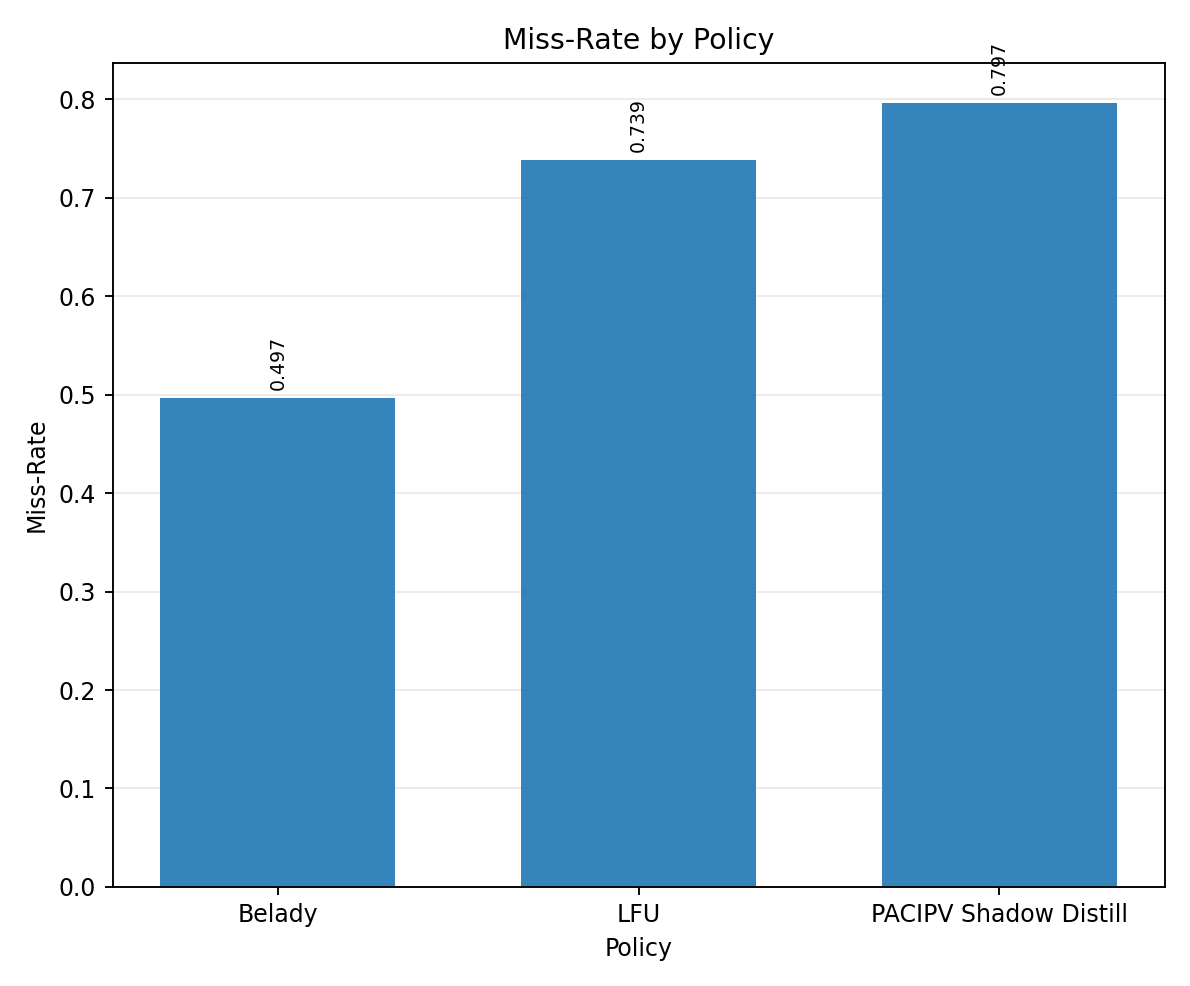

In [57]:
# Plotting: compare PACIPV shadow-distilled policy against LFU and Belady.
!python3 ../scripts/plot_belady_sweep_results.py \
  --sweep-summary-csv ./data/belady_sweep/belady_sweep_summary.csv \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0 \
  --policies belady,lfu,pacipv_shadow \
  --summary-csv data/belady_sweep/plot_lookup_summary.csv \
  --plot-file-format png

from IPython.display import Image, display
display(Image("figures/belady_sweep/belady_lookup_train_workload.selected_qualcomm_srv_ap_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_train_fraction.1.0_bar_miss_rates_by_policy.png", 
width=600, height=600))


In [59]:
!cat data/belady_sweep/pacipv_shadow_vectors_selected_qualcomm_srv_ap_to_selected_qualcomm_srv_ap_s64_w16_frac1p000_rrpv3_ctx1.txt
!cat data/belady_sweep/pacipv_vectors_selected_qualcomm_srv_ap_to_selected_qualcomm_srv_ap_s64_w16_frac1p000_seedNone.txt

# Learned PACIPV shadow vector
# max_rrpv=3
# reuse_thresholds: T1=1075 T2=2195
# avg_belady_rate=0.438530
# avg_pacipv_rate=0.743042
# avg_pacipv_rate_constrained=0.743042

# Reuse distance statistics
# Total accesses: 24635613
# Dead-on-arrival (state 3): 7647264 (31.0%)
# Short-reuse (states 0-2): 16988349 (69.0%)
# Bucket distribution: s0=5667320, s1=5660519, s2=5660510, s3=7647264

# insert_votes_inst=[721903, 956247, 849678, 1014556]
# insert_vote_probs_inst=[0.20379, 0.269944, 0.239861, 0.286405]
# insert_votes_data=[2036455, 2490858, 2305117, 3521730]
# insert_vote_probs_data=[0.19668, 0.240566, 0.222627, 0.340127]

# hit_votes_raw_inst
#   old=0 counts=[294046, 209734, 227543, 211909]
#   old=1 counts=[206498, 165575, 208618, 262213]
#   old=2 counts=[189803, 167387, 208653, 300223]
#   old=3 counts=[21558, 23833, 33827, 52517]
# hit_vote_probs_raw_inst
#   old=0 probs=[0.311743, 0.222357, 0.241238, 0.224663]
#   old=1 probs=[0.244984, 0.196434, 0.247499, 0.311083]
#   old=2 p

* Possible issues: 
  - If lots of insertions have no future reuse, state 3 will dominate
    - That's actually ok for insert
    - Ignore very long reuses (?)
    - Tune bucket thresholds
  - Hit transitions are learned from old_state -> target_state, where target_state is based on the next reuse distance after the hit
    - A hit now can increase the rrpv value
    - Hit should always promote towards MRU.

  - Fix: Should try:
    - Hit should always promote towards MRU
      - keep monotonicity (new <= old_state)
      - enforce strict promotion for old_state > 0 (new_state <= old_state-1)
      - keep state 0 -> 0

In [ ]:
python3 ./scripts/run_belady_sweep.py \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0 \
  --policies pacipv_shadow \
  --pacipv-shadow-max-rrpvs 3 \
  --pacipv-shadow-per-context \
  --slurm --slurm-time 02:00:00 \
  --summary-csv data/shadow_distill/summary.csv

In [65]:
!../scripts/synch_folder.sh shadow_distill2

!python3 ../scripts/run_belady_sweep.py \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0 \
  --policies pacipv_shadow \
  --pacipv-shadow-max-rrpvs 3 \
  --pacipv-shadow-per-context \
  --summary-csv data/shadow_distill2/summary.csv \
  --collect-existing-results

Syncing experiment: shadow_distill2
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
./
cache_miss_rates_train.selected_qualcomm_srv_ap_eval.selected_qualcomm_srv_ap_s64_w16_pacipv_shadow_rrpv.3_pacipv_shadow_ctx.1_frac.1p000.csv
pacipv_shadow_vectors_selected_qualcomm_srv_ap_to_selected_qualcomm_srv_ap_s64_w16_frac1p000_rrpv3_ctx1.txt
summary.csv

sent 155 bytes  received 8,613 bytes  5,845.33 bytes/sec
total size is 8,115  speedup is 0.93
Total configurations: 1
Collected existing results: ok=1, missing=0
Summary written to data/shadow_distill2/summary.csv


In [66]:
! cat data/shadow_distill2/pacipv_shadow_vectors_selected_qualcomm_srv_ap_to_selected_qualcomm_srv_ap_s64_w16_frac1p000_rrpv3_ctx1.txt

# Learned PACIPV shadow vector
# max_rrpv=3
# avg_belady_rate=0.496666
# avg_pacipv_rate=0.796553
# avg_pacipv_rate_constrained=0.728712

# insert_votes_inst=[728844, 873761, 829763, 1072670]
# insert_vote_probs_inst=[0.207942, 0.249287, 0.236734, 0.306037]
# insert_votes_data=[2219971, 2383616, 2110386, 3541725]
# insert_vote_probs_data=[0.216462, 0.232419, 0.205777, 0.345342]

# hit_votes_raw_inst
#   old=0 counts=[191417, 226976, 228834, 216876]
#   old=1 counts=[219924, 171968, 230811, 318120]
#   old=2 counts=[197678, 161329, 204259, 321294]
#   old=3 counts=[22404, 21377, 31839, 56177]
# hit_vote_probs_raw_inst
#   old=0 probs=[0.221521, 0.262672, 0.264823, 0.250984]
#   old=1 probs=[0.233757, 0.182785, 0.245329, 0.338129]
#   old=2 probs=[0.223476, 0.182383, 0.230916, 0.363225]
#   old=3 probs=[0.169989, 0.162196, 0.241576, 0.426239]
# hit_votes_clipped_inst
#   old=0 counts=[191417, 226976, 228834, 216876]
#   old=1 counts=[219924, 171968, 230811, 318120]
#   old=2 counts=[1976

* Clipping monotonically produces better vectors
  - Need to evaluate them. they were not in the exhaustive search space
    - Fixed by adding more constrains - the found vector was still not a good one before
  - data/instr vectors can differ
  - Next steps:
    - Find min training set
    - Check results for single benchmark training (overfitting)

In [ ]:
python3 ./scripts/run_belady_sweep.py \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --policies pacipv \
  --pacipv-demand-vector 0,0,0,2,3 \
  --slurm --slurm-time 02:00:00 \
  --summary-csv data/eval_ipv/eval_summary.csv

In [5]:
!../scripts/synch_folder.sh eval_ipv_complete

!python3 ../scripts/run_belady_sweep.py \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 0.2 \
  --policies belady,lfu,pacipv_shadow \
  --summary-csv data/eval_ipv_complete/eval_summary.csv \
  --collect-existing-results

Syncing experiment: eval_ipv_complete
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
eval_summary.csv

sent 126 bytes  received 1,541 bytes  3,334.00 bytes/sec
total size is 13,596  speedup is 8.16
Total configurations: 1
Collected existing results: ok=1, missing=0
Summary written to data/eval_ipv_complete/eval_summary.csv


Lookup summary written to data/eval_ipv_complete/plot_lookup_summary.csv
Found 1, missing 0
Baseline values for non-varied features:
  tw=selected_qualcomm_srv_ap|ew=selected_qualcomm_srv_ap|s=64|w=16|f=0.2
Skipping eval_workload: only one feature value after fixing others to baseline.
Skipping num_sets: only one feature value after fixing others to baseline.
Skipping num_ways: only one feature value after fixing others to baseline.
Bar values by policy:
  Belady: 0.496615
  LFU: 0.738690
  PACIPV: 0.727762
  PACIPV Shadow Distill: 0.728498
Generated plots:
  figures/belady_sweep/belady_lookup_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_bar_miss_rates_by_policy.png


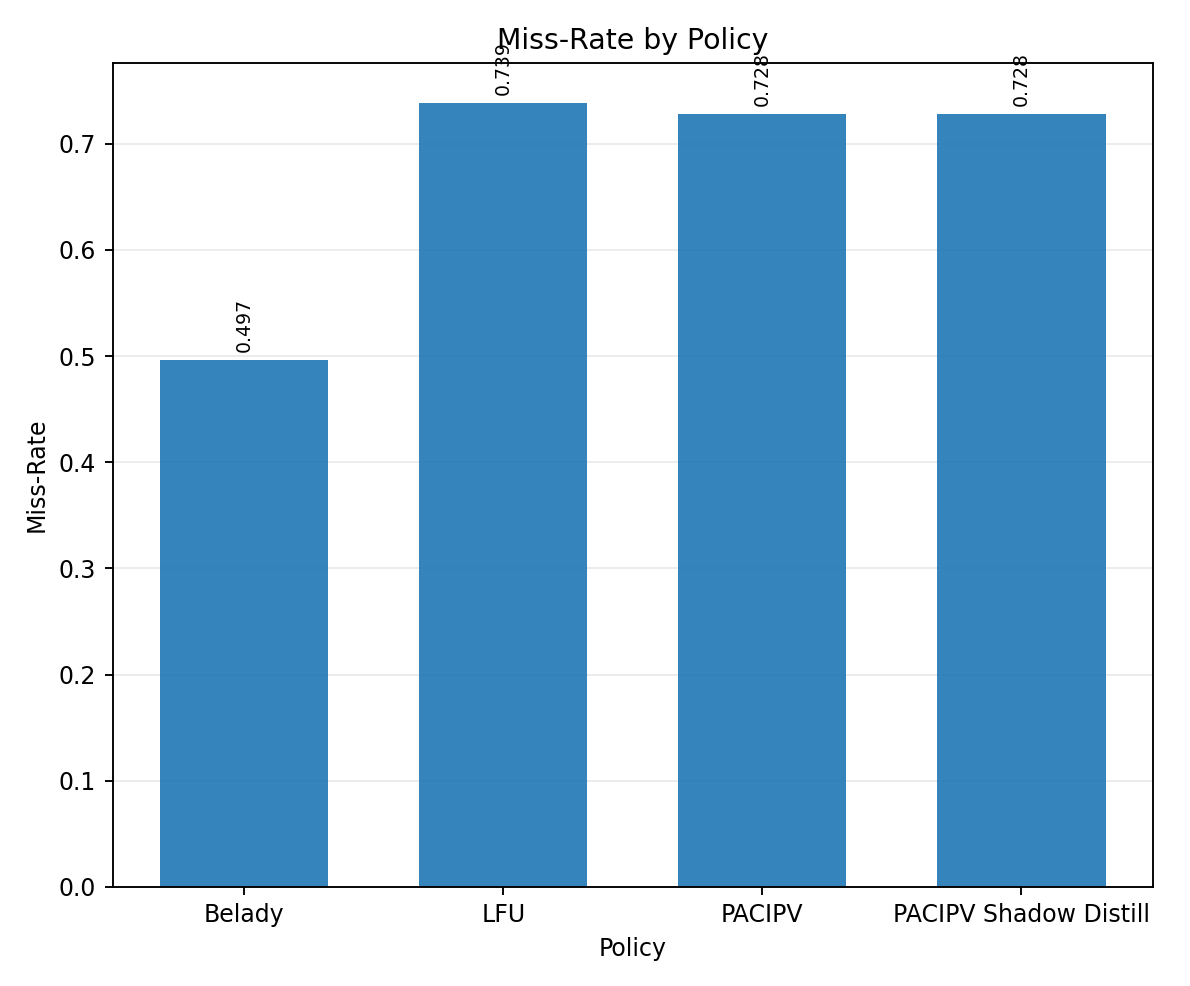

In [7]:
# Plotting: compare PACIPV shadow-distilled policy against LFU and Belady.
!python3 ../scripts/plot_belady_sweep_results.py \
  --sweep-summary-csv ./data/eval_ipv_complete/eval_summary.csv \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --policies belady,lfu,pacipv,pacipv_shadow \
  --summary-csv data/eval_ipv_complete/plot_lookup_summary.csv \
  --plot-file-format png

from IPython.display import Image, display
display(Image("figures/belady_sweep/belady_lookup_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_bar_miss_rates_by_policy.png", 
width=600, height=600))

***
### Training size sweep
* Which is the min training size we can still get a good IPV vector?

In [ ]:
python3 ./scripts/run_belady_sweep.py  \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0,0.8,0.5,0.2,0.1 \
  --policies pacipv_shadow \
  --pacipv-shadow-max-rrpvs 3 \
  --pacipv-shadow-per-context \
  --slurm --slurm-time 08:00:00 \
  --summary-csv data/sweep_train_fraction/summary.csv
  

In [76]:
!../scripts/synch_folder.sh sweep_train_fraction

!python3 ../scripts/run_belady_sweep.py  \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0,0.8,0.5,0.2,0.1 \
  --policies pacipv_shadow \
  --pacipv-shadow-max-rrpvs 3 \
  --pacipv-shadow-per-context \
  --slurm --slurm-time 08:00:00 \
  --summary-csv data/sweep_train_fraction/summary.csv \
  --collect-existing-results

Syncing experiment: sweep_train_fraction
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
./
cache_miss_rates_train.selected_qualcomm_srv_ap_eval.selected_qualcomm_srv_ap_s64_w16_pacipv_shadow_rrpv.3_pacipv_shadow_ctx.1_frac.0p100.csv
cache_miss_rates_train.selected_qualcomm_srv_ap_eval.selected_qualcomm_srv_ap_s64_w16_pacipv_shadow_rrpv.3_pacipv_shadow_ctx.1_frac.0p200.csv
cache_miss_rates_train.selected_qualcomm_srv_ap_eval.selected_qualcomm_srv_ap_s64_w16_pacipv_shadow_rrpv.3_pacipv_shadow_ctx.1_frac.0p500.csv
cache_miss_rates_train.selected_qualcomm_srv_ap_eval.selected_qualcomm_srv_ap_s64_w16_pacipv_shadow_rrpv.3_pacipv_shadow_ctx.1_frac.0p800.csv
cache_miss_rates_train.selected_qualcomm_srv_ap_eval.selected_qualcomm_srv_ap_s64_w16_pacipv_shadow_rrpv

Lookup summary written to data/sweep_train_fraction/plot_lookup_summary.csv
Found 5, missing 0
Baseline values for non-varied features:
  tw=selected_qualcomm_srv_ap|ew=selected_qualcomm_srv_ap|s=64|w=16|f=1.0
Bar values for Training Fraction:
  PACIPV Shadow Distill @ 0.1: 0.746032
  PACIPV Shadow Distill @ 0.2: 0.728556
  PACIPV Shadow Distill @ 0.5: 0.728805
  PACIPV Shadow Distill @ 0.8: 0.728534
  PACIPV Shadow Distill @ 1.0: 0.728446
Skipping train_workload: only one feature value after fixing others to baseline.
Skipping eval_workload: only one feature value after fixing others to baseline.
Skipping num_sets: only one feature value after fixing others to baseline.
Skipping num_ways: only one feature value after fixing others to baseline.
Generated plots:
  figures/belady_sweep/belady_lookup_train_workload.selected_qualcomm_srv_ap_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_train_fraction.multi_bar_miss_rates_vs_train_fraction.png


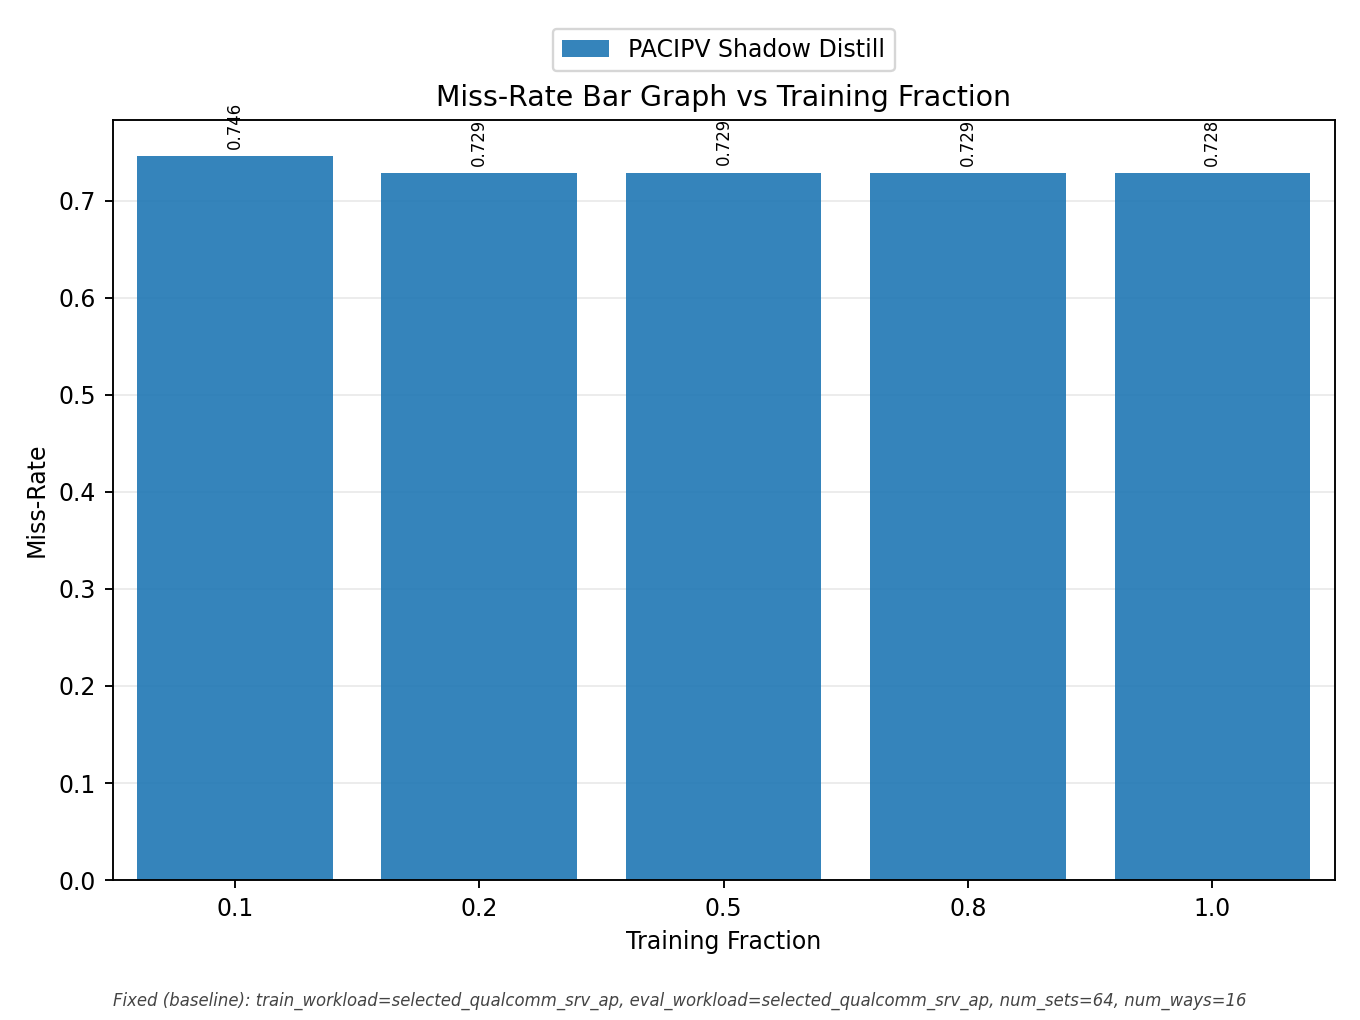

In [78]:
!python3 ../scripts/plot_belady_sweep_results.py \
  --sweep-summary-csv ./data/sweep_train_fraction/summary.csv \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0,0.8,0.5,0.2,0.1 \
  --policies pacipv_shadow \
  --summary-csv data/sweep_train_fraction/plot_lookup_summary.csv \
  --plot-file-format png

from IPython.display import Image, display
display(Image("figures/belady_sweep/belady_lookup_train_workload.selected_qualcomm_srv_ap_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_train_fraction.multi_bar_miss_rates_vs_train_fraction.png", 
width=600, height=600))

### Training set different from evaluation set
* Can we train with google_srv and run with qualcomm_srv?

In [ ]:
python3 ./scripts/run_belady_sweep.py  \
  --train-workloads google_srv \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 0.1,0.2,0.5,0.8,1.0 \
  --policies pacipv_shadow \
  --pacipv-shadow-max-rrpvs 3 \
  --pacipv-shadow-per-context \
  --slurm --slurm-time 08:00:00 \
  --summary-csv data/sweep_train_fraction/summary.csv

In [2]:
!../scripts/synch_folder.sh sweep_train_fraction

!python3 ../scripts/run_belady_sweep.py  \
  --train-workloads google_srv \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 0.1,0.2,0.5,0.8,1.0 \
  --policies pacipv_shadow \
  --pacipv-shadow-max-rrpvs 3 \
  --pacipv-shadow-per-context \
  --summary-csv data/sweep_train_fraction/summary.csv \
  --collect-existing-results

Syncing experiment: sweep_train_fraction
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
summary.csv

sent 138 bytes  received 4,917 bytes  3,370.00 bytes/sec
total size is 72,761  speedup is 14.39
Total configurations: 5
Collected existing results: ok=5, missing=0
Summary written to data/sweep_train_fraction/summary.csv


Lookup summary written to data/sweep_train_fraction/plot_lookup_summary.csv
Found 5, missing 0
Baseline values for non-varied features:
  tw=google_srv|ew=selected_qualcomm_srv_ap|s=64|w=16|f=0.1
Bar values for Training Fraction:
  PACIPV Shadow Distill @ 0.1: 0.728528
  PACIPV Shadow Distill @ 0.2: 0.728569
  PACIPV Shadow Distill @ 0.5: 0.728846
  PACIPV Shadow Distill @ 0.8: 0.728828
  PACIPV Shadow Distill @ 1.0: 0.728629
Skipping train_workload: only one feature value after fixing others to baseline.
Skipping eval_workload: only one feature value after fixing others to baseline.
Skipping num_sets: only one feature value after fixing others to baseline.
Skipping num_ways: only one feature value after fixing others to baseline.
Generated plots:
  figures/belady_sweep/belady_lookup_train_workload.google_srv_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_train_fraction.multi_bar_miss_rates_vs_train_fraction.png


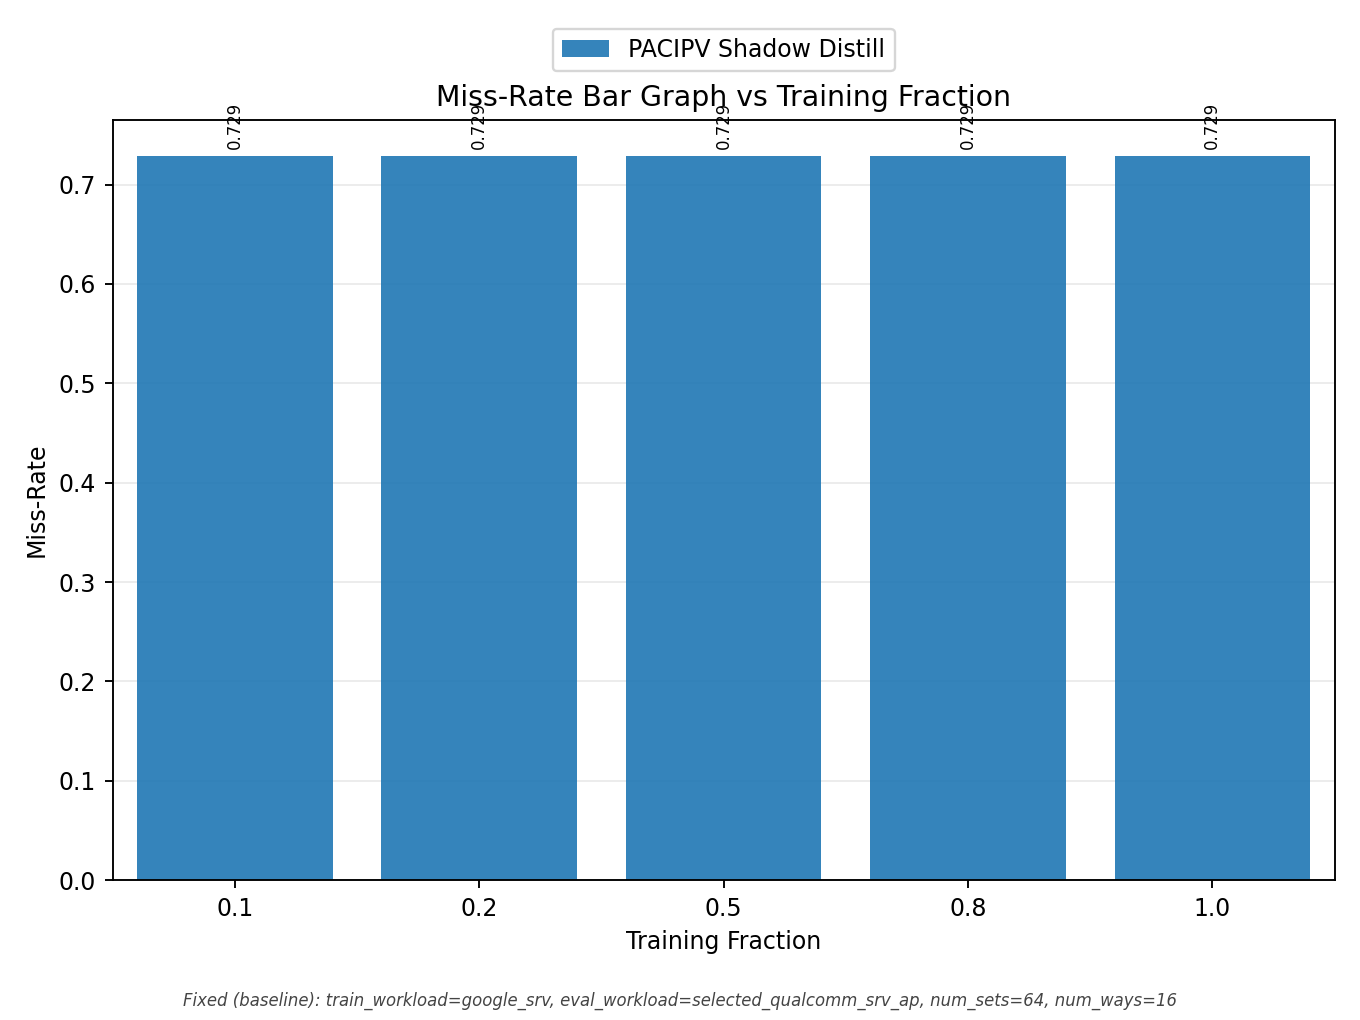

In [6]:
!python3 ../scripts/plot_belady_sweep_results.py \
  --sweep-summary-csv ./data/sweep_train_fraction/summary.csv \
  --train-workloads google_srv \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --train-fractions 1.0,0.8,0.5,0.2,0.1 \
  --policies pacipv_shadow \
  --summary-csv data/sweep_train_fraction/plot_lookup_summary.csv \
  --plot-file-format png

from IPython.display import Image, display
display(Image("figures/belady_sweep/belady_lookup_train_workload.google_srv_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_train_fraction.multi_bar_miss_rates_vs_train_fraction.png", 
width=600, height=600))

***
### Overfitting with single benchmark train/eval


In [ ]:
python3 ./scripts/run_belady_sweep.py \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --policies belady,lfu,pacipv,pacipv_shadow \
  --pacipv-demand-vector 0,0,1,2,3 \
  --slurm --slurm-time 08:00:00 \
  --summary-csv data/per_bench_train/eval_summary.csv \
  --train-workloads selected_qualcomm_srv_ap \
  --pacipv-train-per-benchmark \
  --pacipv-shadow-train-per-benchmark

In [82]:
!../scripts/synch_folder.sh per_bench_train

!python3 ../scripts/run_belady_sweep.py \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --policies belady,lfu,pacipv,pacipv_shadow \
  --summary-csv data/per_bench_train/eval_summary.csv \
  --train-workloads selected_qualcomm_srv_ap \
  --pacipv-train-per-benchmark \
  --pacipv-shadow-train-per-benchmark \
  --collect-existing-results

Syncing experiment: per_bench_train
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 91 bytes  received 304 bytes  263.33 bytes/sec
total size is 7,860  speedup is 19.90
Total configurations: 1
Collected existing results: ok=1, missing=0
Summary written to data/per_bench_train/eval_summary.csv


Lookup summary written to data/per_bench_train/plot_lookup_summary.csv
Found 1, missing 0
Baseline values for non-varied features:
  tw=selected_qualcomm_srv_ap|ew=selected_qualcomm_srv_ap|s=64|w=16
Skipping train_workload: only one feature value after fixing others to baseline.
Skipping eval_workload: only one feature value after fixing others to baseline.
Skipping num_sets: only one feature value after fixing others to baseline.
Skipping num_ways: only one feature value after fixing others to baseline.
Bar values by policy:
  PACIPV: 0.720935
  PACIPV Shadow Distill: 0.730749
Generated plots:
  figures/belady_sweep/belady_lookup_train_workload.selected_qualcomm_srv_ap_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_bar_miss_rates_by_policy.png


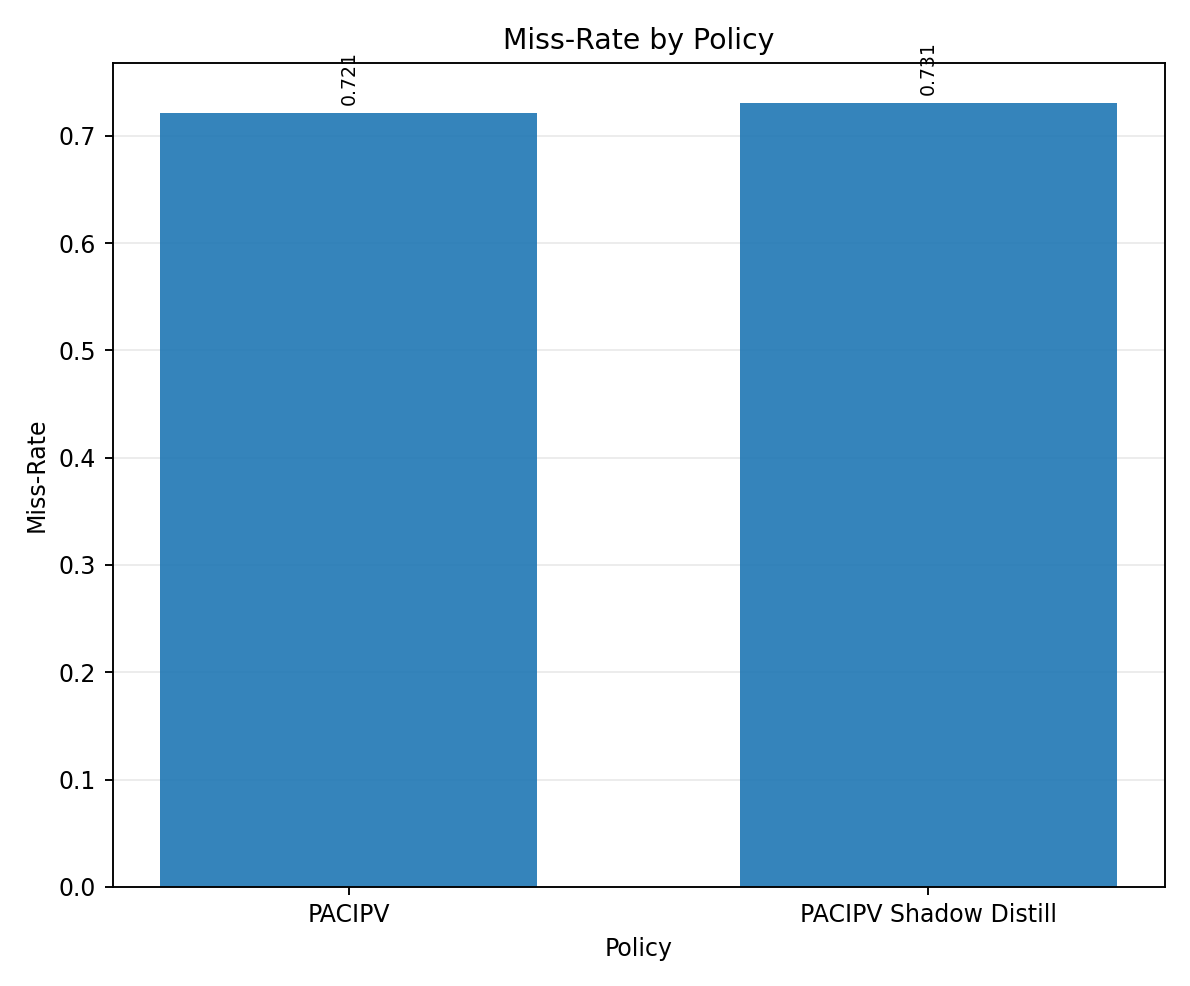

In [5]:
!python3 ../scripts/plot_belady_sweep_results.py \
  --sweep-summary-csv ./data/per_bench_train/eval_summary.csv \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --policies pacipv,pacipv_shadow \
  --summary-csv data/per_bench_train/plot_lookup_summary.csv \
  --plot-file-format png

from IPython.display import Image, display
display(Image("figures/belady_sweep/belady_lookup_train_workload.selected_qualcomm_srv_ap_eval_workload.selected_qualcomm_srv_ap_num_sets.64_num_ways.16_bar_miss_rates_by_policy.png", 
width=600, height=600))

***
### (!) Probabilistic IPV
* Instdead of fixed values for each IPV cell
  - Use a distributions vector [p1,p2,p3,p4] modeling how often a value should be chosen.
  - Vector is now a matrix of positions and rrpv value distributions 
  - Should model similar constrains with pacipv vector (i.e. monotonicity)

In [ ]:
python ./scripts/run_belady_sweep.py \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 \
  --num-ways-list 16 \
  --train-fractions 1.0 \
  --policies belady,lfu,pacipv_shadow_dist \
  --pacipv-shadow-max-rrpvs 3 \
  --pacipv-shadow-per-context \
  --summary-csv ./data/prob_ipv/summary.csv \
  --slurm --slurm-time 04:00:00

In [11]:
!../scripts/synch_folder.sh prob_ipv

!python ../scripts/run_belady_sweep.py \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 \
  --num-ways-list 16 \
  --train-fractions 1.0 \
  --policies belady,lfu,pacipv_shadow_dist \
  --pacipv-shadow-max-rrpvs 3 \
  --summary-csv ./data/prob_ipv/summary.csv \
  --collect-existing-results

Syncing experiment: prob_ipv
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 91 bytes  received 253 bytes  229.33 bytes/sec
total size is 8,029  speedup is 23.34
Total configurations: 1
Collected existing results: ok=0, missing=1
Summary written to data/prob_ipv/summary.csv


In [ ]:
!python3 ../scripts/plot_belady_sweep_results.py \
  --sweep-summary-csv ./data/prob_ipv/summary.csv \
  --train-workloads selected_qualcomm_srv_ap \
  --eval-workloads selected_qualcomm_srv_ap \
  --num-sets-list 64 --num-ways-list 16 \
  --policies belady,lfu,pacipv_shadow_dist \
  --summary-csv data/prob_ipv/plot_lookup_summary.csv \
  --plot-file-format png

from IPython.display import Image, display
display(Image("figures/xxx.png", 
width=600, height=600))

- Couldn't get parse script run, but results are similar
    * Average belady rate: 0.4966
    * Average lfu rate:    0.7391
    * Average pacipv-shadow-dist rate: 0.7887

***
### (!) More contexts?
- PC based?